In [1]:
%matplotlib widget

import os
import numpy as np
import pandas as pd
import ipywidgets as W
import matplotlib.pyplot as plt
from GCRsim_v02f import CosmicRaySimulation
from typing import Tuple, Optional, Union
from IPython.display import display
from dataclasses import dataclass
from scipy.stats import norm

In [2]:
def energy_deposition_stats(
    df: pd.DataFrame,
    pid_col: str = "PID",
    x_col: str = "x", # microns in energy deposition data
    y_col: str = "y") -> pd.DataFrame:
    """
    Group by parent PID (via CosmicRaySimulation.get_parent_pid) and return:
      - avg_x, avg_y  (means in microns)
      - count (total number of energy depositions, including from delta rays)
      - mean_x_px, mean_y_px (means converted to pixels)
      - std_x_px, std_y_px   (per-parent std dev in pixels, from CSV hits)
      - sigma_r_csv          (geometric mean of std_x_px and std_y_px)

    Parameters
    ----------
    df : DataFrame with columns pid_col, x_col, y_col.
          x_col, y_col are in microns.

    Returns
    -------
    DataFrame indexed by parent_pid with added pixel-space stats and sigma_r_ed.
    """
    microns_per_pixel = 10.0
    
    cols = [pid_col, x_col, y_col]
    dfw = df[cols].copy()

    # Parent PID
    dfw["parent_pid"] = dfw[pid_col].map(CosmicRaySimulation.get_parent_pid).astype(np.int64)

    g = dfw.groupby("parent_pid", sort=False, observed=True)

    # means and stds in µm, then convert to px 
    agg = g.agg(
        mean_x_um=(x_col, "mean"),
        mean_y_um=(y_col, "mean"),
        std_x_um=(x_col, "std"),   # sample std ddof=1
        std_y_um=(y_col, "std"),
        count=(x_col, "size"),
    )
    # Convert to pixels
    agg["mean_x_px"] = agg["mean_x_um"] / microns_per_pixel
    agg["mean_y_px"] = agg["mean_y_um"] / microns_per_pixel
    agg["std_x_px"]  = agg["std_x_um"] / microns_per_pixel
    agg["std_y_px"]  = agg["std_y_um"] / microns_per_pixel

    # Scalar proxy for spread (pixels)
    agg["sigma_r_ed"] = np.sqrt(agg["std_x_px"] * agg["std_y_px"])

    agg = agg.reset_index()
    agg["pid_label"] = agg["parent_pid"].map(CosmicRaySimulation.decode_pid)
    agg = agg.set_index("parent_pid")

    # column order
    col_order = [
        "mean_x_um", "mean_y_um", # µm
        "mean_x_px", "mean_y_px", # px
        "std_x_um", "std_y_um", # µm (for reference)
        "std_x_px", "std_y_px", # px
        "sigma_r_ed",  # px
        "count", "pid_label"
    ]

    # Keep only existing columns, in order
    col_order = [c for c in col_order if c in agg.columns]
    return agg[col_order]

In [3]:
raw_df = pd.read_csv("./Outputs/validation tests/energyDepositions_d2020_352_run1.csv")

stats_df = energy_deposition_stats(raw_df)

print(stats_df.head())

               mean_x_um     mean_y_um    mean_x_px    mean_y_px  std_x_um  \
parent_pid                                                                   
16384       17467.704894  18096.205967  1746.770489  1809.620597  1.318560   
33570816    32861.101047  23777.641286  3286.110105  2377.764129  0.700168   
33587200    37302.169744  11187.763549  3730.216974  1118.776355  1.073046   
33603584    11960.786093   7562.050408  1196.078609   756.205041  0.495597   
33685504    30868.297725  11496.792536  3086.829773  1149.679254  6.906489   

            std_y_um  std_x_px  std_y_px  sigma_r_ed  count       pid_label  
parent_pid                                                                   
16384       2.179724  0.131856  0.217972    0.169532    101  e-P0001-D00000  
33570816    2.051489  0.070017  0.205149    0.119849   2750  H-P0001-D00000  
33587200    1.322238  0.107305  0.132224    0.119114   2056  H-P0002-D00000  
33603584    1.185296  0.049560  0.118530    0.076644    392  H-

In [4]:
#  patch viewer
ArrayLike = Union[np.ndarray, np.memmap]

@dataclass
class MomentParams:
    half_size: int = 32
    min_pixels: int = 3
    max_pixels: int = 200_000
    seed_on_round: bool = True
    positive_threshold: float = 0.0  # pixels > threshold are signal

def _extract_patch(img: ArrayLike, x: int, y: int, half: int) -> Tuple[np.ndarray, Tuple[int,int]]:
    H, W = img.shape
    x0 = max(0, x - half); y0 = max(0, y - half)
    x1 = min(W, x + half + 1); y1 = min(H, y + half + 1)
    return img[y0:y1, x0:x1], (x0, y0)

def _flood_fill(mask: np.ndarray, seed_xy: Tuple[int,int]) -> np.ndarray:
    H, W = mask.shape
    sx, sy = seed_xy
    if not (0 <= sx < W and 0 <= sy < H) or not mask[sy, sx]:
        return np.zeros_like(mask, dtype=bool)
    out = np.zeros_like(mask, dtype=bool)
    stack = [(sx, sy)]
    out[sy, sx] = True
    nbrs = [(-1,-1),(0,-1),(1,-1),(-1,0),(1,0),(-1,1),(0,1),(1,1)]
    while stack:
        x, y = stack.pop()
        for dx, dy in nbrs:
            nx, ny = x+dx, y+dy
            if 0 <= nx < W and 0 <= ny < H and (not out[ny, nx]) and mask[ny, nx]:
                out[ny, nx] = True
                stack.append((nx, ny))
    return out

def create_floodfill_viewer(
    img: ArrayLike,
    parent_df: pd.DataFrame,
    *,
    x_seed_col: str = "avg_x (microns)",
    y_seed_col: str = "avg_y (microns)",
    label_col: Optional[str] = "pid_label",   
    params: MomentParams = MomentParams(), microns_per_pixel: float = 10.0
):
    """
    Interactive viewer for verifying flood-fill windows.
    Requirements on parent_df:
      - index: parent_pid (ints)
      - columns: x_seed_col, y_seed_col (floats)
        already computed image-based centroids to display.
      - label_col (e.g., 'pid_label') for nicer dropdown text.
    """

    # Build dropdown choices
    def _choice_for_pid(pid):
        if label_col and label_col in parent_df.columns:
            return f"{pid} | {parent_df.loc[pid, label_col]}"
        return str(pid)

    parent_pids = parent_df.index.to_list()
    choices = { _choice_for_pid(pid): pid for pid in parent_pids }

    dd = W.Dropdown(options=choices, description="Event:", layout=W.Layout(width="60%"))
    half_slider = W.IntSlider(params.half_size, 16, 256, 1, description="Half-size")
    thr_box = W.FloatText(value=params.positive_threshold, description="> DN")
    show_seed = W.Checkbox(True, description="Show seed (avg_x,avg_y)")
    stretch = W.FloatSlider(value=1.0, min=0.2, max=5.0, step=0.1, description="Contrast")
    info = W.HTML("")

    controls = W.HBox([dd, half_slider, thr_box, show_seed, stretch])

    out = W.Output()
    decoder = CosmicRaySimulation(grid_size=2)
    def _plot(_=None):
        with out:
            out.clear_output()
            pid = dd.value
            half = int(half_slider.value)
            thr = float(thr_box.value)

            # Seed (global)
            sx_f = float(parent_df.loc[pid, x_seed_col]) / microns_per_pixel
            sy_f = float(parent_df.loc[pid, y_seed_col]) / microns_per_pixel
            sx = int(round(sx_f)) if params.seed_on_round else int(np.floor(sx_f))
            sy = int(round(sy_f)) if params.seed_on_round else int(np.floor(sy_f))

            # Window + mask + flood-fill
            patch, (x0, y0) = _extract_patch(img, sx, sy, half)
            seed_local = (sx - x0, sy - y0)
            mask = patch > thr
            comp = _flood_fill(mask, seed_local)
            n_pix = int(comp.sum())

            Ht, Wd = patch.shape
            extent = (x0, x0+Wd, y0+Ht, y0)  # so imshow aligns with global coords (origin top-left)

            fig = plt.figure(figsize=(8, 6))
            ax = fig.add_subplot(111)
            ax.imshow(patch, cmap="gray", origin="upper", extent=extent, interpolation="nearest")

            # Overlay flood-filled pixels (semi-transparent)
            comp_alpha = np.zeros((*comp.shape, 4), dtype=float)
            comp_alpha[comp] = [1, 0, 0, 0.25]  # red with alpha
            ax.imshow(comp_alpha, origin="upper", extent=extent, interpolation="nearest")

            # Red boundary via contour
            if comp.any():
                # contour expects 2D scalar field; use comp.astype(int)
                # draw at 0.5 to get the edge between 0 and 1
                ax.contour(comp.astype(int), levels=[0.5], colors="red", linewidths=1.5,
                           origin="upper", extent=extent)

            # Seed marker
            if show_seed.value:
                ax.plot([sx],[sy], marker="x", ms=10, mew=2, color="yellow", label="seed")

            ax.set_title(f"parent_pid={decoder.decode_pid(pid)} | window [{x0}:{x0+Wd}, {y0}:{y0+Ht}] | flood pix={n_pix}")
            ax.set_xlabel("x (px)"); ax.set_ylabel("y (px)")
            ax.legend(loc="lower right")
            ax.set_aspect("equal")
            plt.show()

            info.value = f"<code>Seed=({sx},{sy})</code> &nbsp; <code>Half={half}</code> &nbsp; <code>thr&gt;{thr}</code> &nbsp; <code>flood_pix={n_pix}</code>"

    # Wire up interactions
    for w in (dd, half_slider, thr_box, show_seed, stretch):
        w.observe(_plot, names="value")
    _plot()  # initial draw

    display(controls, out, info)


In [7]:
# img: 4096x4096 DN frame (numpy array or memmap)
# stats_df: output of energy_deposition_stats(...)
img = np.load("./Outputs/validation tests/DNmap_d2020_352_run1.npy")
# Example (using pid_label if present):
create_floodfill_viewer(img, stats_df, x_seed_col="mean_x_um", y_seed_col="mean_y_um",
                        label_col="pid_label",
                        params=MomentParams(half_size=32,positive_threshold=0.0))


Output()

HTML(value='<code>Seed=(1747,1810)</code> &nbsp; <code>Half=32</code> &nbsp; <code>thr&gt;0.0</code> &nbsp; <c…

In [8]:
def image_moments(patch: np.ndarray, mask: np.ndarray) -> Optional[dict]:
    """Compute sum, centroid, covariance, principal axes, orientation."""
    ys, xs = np.nonzero(mask)
    if xs.size == 0:
        return None
    w = patch[ys, xs].astype(np.float64)
    M00 = w.sum()
    if M00 <= 0:
        return None

    x = xs.astype(np.float64)
    y = ys.astype(np.float64)

    M10 = np.dot(x, w); M01 = np.dot(y, w)
    xbar = M10 / M00;   ybar = M01 / M00

    dx = x - xbar; dy = y - ybar
    M20c = np.dot(dx*dx, w)
    M02c = np.dot(dy*dy, w)
    M11c = np.dot(dx*dy, w)

    cov_xx = M20c / M00
    cov_yy = M02c / M00
    cov_xy = M11c / M00

    tr = cov_xx + cov_yy
    det = max(cov_xx*cov_yy - cov_xy*cov_xy, 0.0)
    disc = max(tr*tr/4 - det, 0.0)
    lam1 = max(tr/2 + np.sqrt(disc), 0.0)  # major
    lam2 = max(tr/2 - np.sqrt(disc), 0.0)  # minor
    sigma_major = np.sqrt(lam1)
    sigma_minor = np.sqrt(lam2)
    theta = 0.5 * np.arctan2(2*cov_xy, (cov_xx - cov_yy))

    return dict(
        M00=M00,
        xbar_local=xbar, ybar_local=ybar,
        cov_xx=cov_xx, cov_yy=cov_yy, cov_xy=cov_xy,
        sigma_major=sigma_major, sigma_minor=sigma_minor, theta=theta,
        n_pix=int(xs.size),
    )

def augment_with_image_moments(
    img: ArrayLike,
    parent_df: pd.DataFrame,
    x_seed_col: str = "mean_x_um",  # energy deposition data in µm
    y_seed_col: str = "mean_y_um", 
    params: MomentParams = MomentParams(),
    microns_per_pixel: float = 10.0
) -> pd.DataFrame:
    """
    Zero-background fast path:
      - mask = (DN > positive_threshold)
      - flood-fill component containing the seed (seed from CSV, in µm)
      - compute M00, centroid, covariance, principal axes, orientation (in pixels)
    Returns parent_df + new columns, indexed by parent_pid.
    """
    out_cols = [
        "flux_M00","xbar","ybar",
        "cov_xx","cov_yy","cov_xy",
        "sigma_major","sigma_minor","theta_rad",
        "n_pix","win_x0","win_y0","status"
    ]
    rows = []

    H, W = img.shape

    for parent_pid, row in parent_df.iterrows():
        # Convert seed from µm -> px
        sx_f = float(row[x_seed_col]) / microns_per_pixel
        sy_f = float(row[y_seed_col]) / microns_per_pixel
        sx = int(round(sx_f)) if params.seed_on_round else int(np.floor(sx_f))
        sy = int(round(sy_f)) if params.seed_on_round else int(np.floor(sy_f))

        # Extract window
        patch, (x0, y0) = _extract_patch(img, sx, sy, params.half_size)
        seed_local = (sx - x0, sy - y0)

        # Zero-background mask + flood-fill
        prelim = patch > params.positive_threshold
        comp = _flood_fill(prelim, seed_local)

        n_pix = int(comp.sum())
        if n_pix < params.min_pixels or n_pix > params.max_pixels:
            rows.append((parent_pid, dict(
                flux_M00=np.nan, xbar=np.nan, ybar=np.nan,
                cov_xx=np.nan, cov_yy=np.nan, cov_xy=np.nan,
                sigma_major=np.nan, sigma_minor=np.nan, theta_rad=np.nan,
                n_pix=n_pix, win_x0=x0, win_y0=y0, status="rejected_npix"
            )))
            continue

        stats = image_moments(patch, comp)
        if stats is None:
            rows.append((parent_pid, dict(
                flux_M00=np.nan, xbar=np.nan, ybar=np.nan,
                cov_xx=np.nan, cov_yy=np.nan, cov_xy=np.nan,
                sigma_major=np.nan, sigma_minor=np.nan, theta_rad=np.nan,
                n_pix=n_pix, win_x0=x0, win_y0=y0, status="no_stats"
            )))
            continue

        # Convert centroid to global pixel coords
        xbar_global = x0 + stats["xbar_local"] 
        ybar_global = y0 + stats["ybar_local"] 

        rec = dict(
            flux_M00=stats["M00"],
            xbar=xbar_global, ybar=ybar_global,      # pixels
            cov_xx=stats["cov_xx"], cov_yy=stats["cov_yy"], cov_xy=stats["cov_xy"],  # px^2
            sigma_major=stats["sigma_major"],       # pixels
            sigma_minor=stats["sigma_minor"],       # pixels
            theta_rad=stats["theta"],
            n_pix=stats["n_pix"], win_x0=x0, win_y0=y0, status="ok"
        )

        rows.append((parent_pid, rec))

    aug = parent_df.copy()
    add = pd.DataFrame.from_dict(dict(rows), orient="index")[out_cols]
    add.index.name = parent_df.index.name or "parent_pid"
    return aug.join(add, how="left")


def process_seeded_blobs(
    img: ArrayLike,
    hits_csv: str,
    out_csv: str,
    win: MomentParams = MomentParams(),
    use_pid_grouping: bool = True
):
    """
    Stream over parent groups derived from CSV x,y (in microns).
    For each, extract a window (in pixels), flood-fill >0 DN, compute moments, and append to out_csv.
    CSV must contain: parent_pid, x, y  (x,y in µm)
    """
    microns_per_pixel= 10.0,
    df = pd.read_csv(hits_csv)

    if use_pid_grouping:
        seeds = (df.groupby("parent_pid")[["x","y"]].mean().reset_index())
    else:
        seeds = df[["parent_pid","x","y"]].drop_duplicates()

    cols = ["parent_pid","flux","x_px","y_px","xbar_px","ybar_px",
            "sigma_major_px","sigma_minor_px","theta_rad","n_pix","x0","y0"]
    header_needed = not os.path.exists(out_csv)
    out_f = open(out_csv, "a", buffering=1)
    if header_needed:
        out_f.write(",".join(cols) + "\n")

    H, W = img.shape
    for _, row in seeds.iterrows():
        # µm -> pixels for seed
        px_um, py_um = float(row["x"]), float(row["y"])
        px = int(round(px_um / microns_per_pixel))
        py = int(round(py_um / microns_per_pixel))

        if not (0 <= px < W and 0 <= py < H):
            continue

        patch, (x0, y0) = _extract_patch(img, px, py, win.half_size)

        prelim = patch > 0.0
        sx, sy = px - x0, py - y0
        comp = _flood_fill(prelim, (sx, sy))

        n_pix = int(comp.sum())
        if n_pix < win.min_pixels or n_pix > win.max_pixels:
            continue

        stats = image_moments(patch, comp)
        if stats is None:
            continue

        xbar = x0 + stats["xbar_local"]
        ybar = y0 + stats["ybar_local"]

        line = [
            str(row["parent_pid"]),
            f"{stats['M00']:.6g}",
            str(px), str(py),
            f"{xbar:.6f}", f"{ybar:.6f}",
            f"{stats['sigma_major']:.6f}", f"{stats['sigma_minor']:.6f}",
            f"{stats['theta']:.6f}",
            str(n_pix), str(x0), str(y0)
        ]
        out_f.write(",".join(line) + "\n")

    out_f.close()


In [9]:
params = MomentParams(half_size=32, positive_threshold=0.0)
aug_df = augment_with_image_moments(img, stats_df, params=params)

# One-number diffusion proxy (pixels)
aug_df["sigma_r_dn"] = np.sqrt(aug_df["sigma_major"] * aug_df["sigma_minor"])
aug_df = aug_df[['pid_label'] + [x for x in aug_df.columns if x != 'pid_label']]
  
aug_df["Var_DN"] = aug_df["sigma_r_dn"]**2  
aug_df["Var_ED"] = aug_df["sigma_r_ed"]**2
aug_df["Var_TH"] = (1/12)
aug_df["Var_CD_derived"] = aug_df["Var_DN"] - aug_df["Var_ED"] - aug_df["Var_TH"]
aug_df["Var_CD_expected"] = (0.314)**2
aug_df["Rel_Error"] = ((aug_df["Var_CD_expected"] - aug_df["Var_CD_derived"])/aug_df["Var_CD_expected"])

aug_df.to_csv("d2020_f352_run1_parent_moments_report.csv", index=False)

aug_df.head()


,pid_label,mean_x_um,mean_y_um,mean_x_px,mean_y_px,std_x_um,std_y_um,std_x_px,std_y_px,sigma_r_ed,...,win_x0,win_y0,status,sigma_r_dn,Var_DN,Var_ED,Var_TH,Var_CD_derived,Var_CD_expected,Rel_Error
parent_pid,,,,,,,,,,,,,,,,,,,,,
16384,e-P0001-D00000,17467.704894,18096.205967,1746.770489,1809.620597,1.318560,2.179724,0.131856,0.217972,0.169532,...,1715,1778,ok,0.417528,0.174330,0.028741,0.083333,0.062255,0.098596,0.368582
33570816,H-P0001-D00000,32861.101047,23777.641286,3286.110105,2377.764129,0.700168,2.051489,0.070017,0.205149,0.119849,...,3254,2346,ok,0.468737,0.219714,0.014364,0.083333,0.122017,0.098596,-0.237545
33587200,H-P0002-D00000,37302.169744,11187.763549,3730.216974,1118.776355,1.073046,1.322238,0.107305,0.132224,0.119114,...,3698,1087,ok,0.439212,0.192907,0.014188,0.083333,0.095386,0.098596,0.032558
33603584,H-P0003-D00000,11960.786093,7562.050408,1196.078609,756.205041,0.495597,1.185296,0.049560,0.118530,0.076644,...,1164,724,ok,0.482522,0.232827,0.005874,0.083333,0.143619,0.098596,-0.456645
33685504,H-P0008-D00000,30868.297725,11496.792536,3086.829773,1149.679254,6.906489,1.950538,0.690649,0.195054,0.367034,...,3055,1118,ok,0.593506,0.352250,0.134714,0.083333,0.134202,0.098596,-0.361135


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


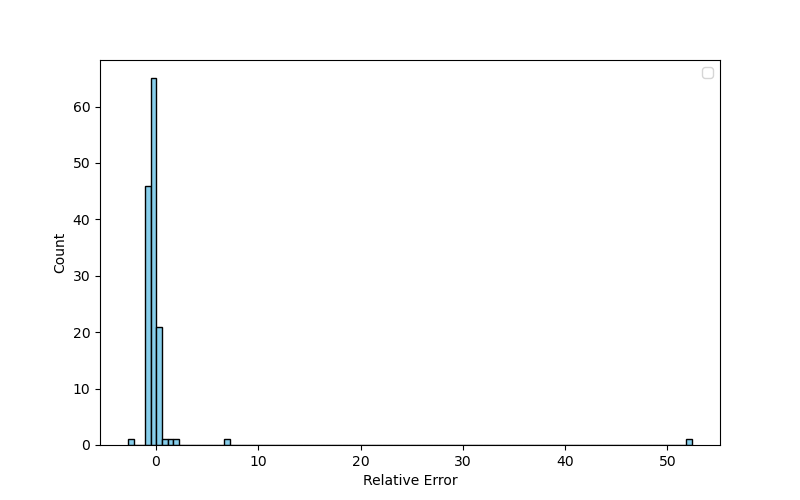

In [10]:
plt.figure(figsize=(8,5))

plt.hist(aug_df["Rel_Error"], bins=100, color="skyblue", edgecolor="k")
plt.xlabel("Relative Error")
plt.ylabel("Count")
plt.legend()
plt.show()

μ = -0.312335, σ = 0.337020, variance = 0.113582


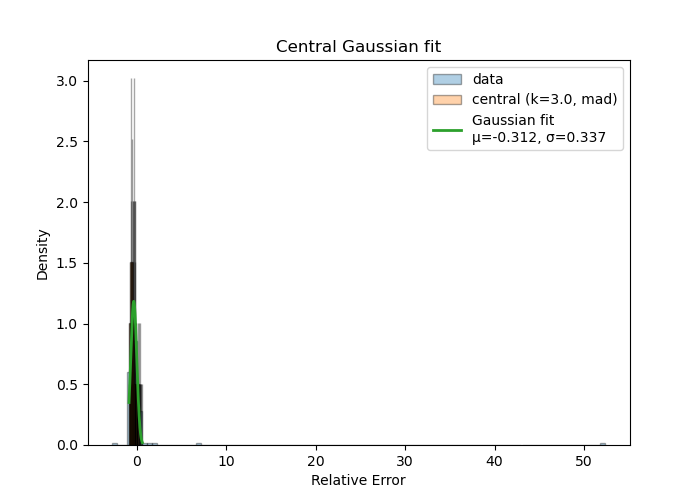

In [11]:
def fit_gaussian_central(data, clip_method="mad", k=3.0, bins=100, ax=None, label="data"):
    """
    Fit a Gaussian to the central bulk of `data`.

    Parameters
    ----------
    data : 1D array-like
        Your samples (e.g., the "Rel_Error" values histogrammed).
    clip_method : {"mad", "iqr", None}
        How to define the central region to fit.
        - "mad": keep points within k * (1.4826 * MAD) of the median (robust σ)
        - "iqr": keep points inside [Q1 - k*IQR, Q3 + k*IQR]
        - None : no clipping (use all points)
    k : float
        Scale for clipping window (default 2.5).
    bins : int
        Number of bins for the display histogram.
    ax : matplotlib.axes.Axes or None
        Axis to draw on; create one if None.
    label : str
        Legend label for the data.

    Returns
    -------
    mu_hat, sigma_hat, var_hat : float
        Fitted mean, standard deviation, and variance (sigma^2).
    mask : boolean array
        Mask of points used in the fit (True = kept).
    """
    x = np.asarray(data)
    x = x[np.isfinite(x)]

    # --- robust central mask ---
    if clip_method == "mad":
        med = np.median(x)
        mad = np.median(np.abs(x - med)) + 1e-12
        sigma_rob = 1.4826 * mad
        mask = (x >= med - k * sigma_rob) & (x <= med + k * sigma_rob)
    elif clip_method == "iqr":
        q1, q3 = np.percentile(x, [25, 75])
        iqr = q3 - q1
        lo, hi = q1 - k * iqr, q3 + k * iqr
        mask = (x >= lo) & (x <= hi)
    else:
        mask = np.ones_like(x, dtype=bool)

    x_fit = x[mask]
    if x_fit.size < 5:
        raise ValueError("Not enough points in central region to fit.")

    # --- Gaussian MLE fit on the selected points ---
    mu_hat, sigma_hat = norm.fit(x_fit)  # MLE; unbiased for large n
    var_hat = sigma_hat**2

    # --- Plot ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    # histogram
    ax.hist(x, bins=bins, density=True, alpha=0.35, edgecolor="k", label=label)
    ax.hist(x_fit, bins=bins, density=True, alpha=0.35, edgecolor="k", label=f"central (k={k}, {clip_method})")

    # fitted curve
    xx = np.linspace(x_fit.min(), x_fit.max(), 400)
    ax.plot(xx, norm.pdf(xx, mu_hat, sigma_hat), lw=2, label=f"Gaussian fit\nμ={mu_hat:.3g}, σ={sigma_hat:.3g}")

    ax.set_xlabel("Relative Error")
    ax.set_ylabel("Density")
    ax.legend()
    ax.set_title("Central Gaussian fit")

    return mu_hat, sigma_hat, var_hat, mask


mu, sigma, var, mask = fit_gaussian_central(aug_df["Rel_Error"], clip_method="mad", k=3.0, bins=100)
print(f"μ = {mu:.6f}, σ = {sigma:.6f}, variance = {var:.6f}")


In [12]:
aug_df["sigma_r_dn_trace"] = np.sqrt(0.5 * (aug_df["sigma_major"]**2 + aug_df["sigma_minor"]**2))
aug_df["var_r_dn_trace"]   = aug_df["sigma_r_dn_trace"]**2   # = 0.5*(σ_maj^2+σ_min^2)

aug_df["sigma_r_ed_trace"] = np.sqrt(0.5 * (aug_df["std_x_px"]**2 + aug_df["std_y_px"]**2))
aug_df["var_r_ed_trace"]   = aug_df["sigma_r_ed_trace"]**2   # = 0.5*(σ_maj^2+σ_min^2)

aug_df["Var_CD_derived"] = aug_df["var_r_dn_trace"] - aug_df["var_r_ed_trace"] - aug_df["Var_TH"]
aug_df["Var_CD_expected"] = (0.314)**2
aug_df["Error"] = ((aug_df["Var_CD_expected"] - aug_df["Var_CD_derived"])/aug_df["Var_CD_expected"])

aug_df.to_csv("d2020_f352_run1_parent_moments_report.csv", index=False)

aug_df.head()

,pid_label,mean_x_um,mean_y_um,mean_x_px,mean_y_px,std_x_um,std_y_um,std_x_px,std_y_px,sigma_r_ed,...,Var_ED,Var_TH,Var_CD_derived,Var_CD_expected,Rel_Error,sigma_r_dn_trace,var_r_dn_trace,sigma_r_ed_trace,var_r_ed_trace,Error
parent_pid,,,,,,,,,,,,,,,,,,,,,
16384,e-P0001-D00000,17467.704894,18096.205967,1746.770489,1809.620597,1.318560,2.179724,0.131856,0.217972,0.169532,...,0.028741,0.083333,0.059579,0.098596,0.368582,0.418762,0.175361,0.180136,0.032449,0.395724
33570816,H-P0001-D00000,32861.101047,23777.641286,3286.110105,2377.764129,0.700168,2.051489,0.070017,0.205149,0.119849,...,0.014364,0.083333,0.113905,0.098596,-0.237545,0.469822,0.220733,0.153278,0.023494,-0.155274
33587200,H-P0002-D00000,37302.169744,11187.763549,3730.216974,1118.776355,1.073046,1.322238,0.107305,0.132224,0.119114,...,0.014188,0.083333,0.097140,0.098596,0.032558,0.441557,0.194972,0.120411,0.014499,0.014763
33603584,H-P0003-D00000,11960.786093,7562.050408,1196.078609,756.205041,0.495597,1.185296,0.049560,0.118530,0.076644,...,0.005874,0.083333,0.141980,0.098596,-0.456645,0.483287,0.233566,0.090844,0.008253,-0.440017
33685504,H-P0008-D00000,30868.297725,11496.792536,3086.829773,1149.679254,6.906489,1.950538,0.690649,0.195054,0.367034,...,0.134714,0.083333,0.099449,0.098596,-0.361135,0.663553,0.440303,0.507465,0.257521,-0.008650


μ = -0.256362, σ = 0.355756, variance = 0.126562


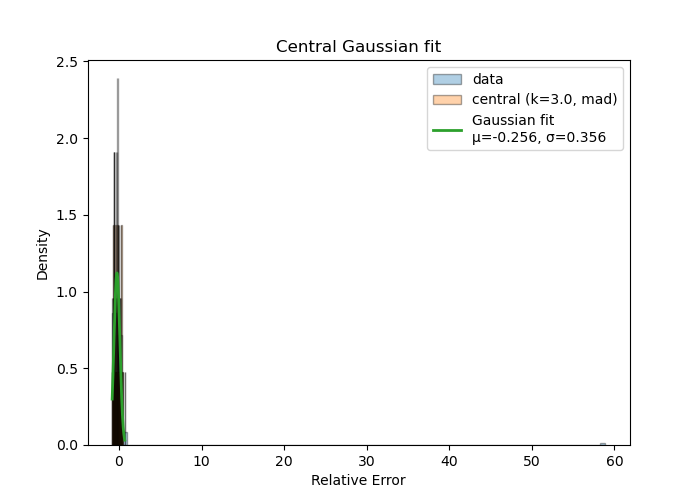

In [13]:
mu, sigma, var, mask = fit_gaussian_central(aug_df["Error"], clip_method="mad", k=3.0, bins=100)
print(f"μ = {mu:.6f}, σ = {sigma:.6f}, variance = {var:.6f}")

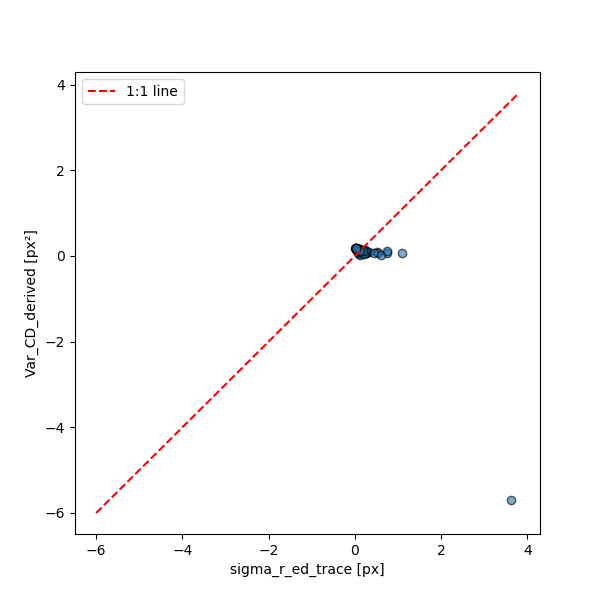

Pearson correlation coefficient r = -0.914


In [16]:
# Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(aug_df["sigma_r_ed_trace"], aug_df["Var_CD_derived"],
            alpha=0.6, edgecolor="k")
plt.ylabel("Var_CD_derived [px²]")
plt.xlabel("sigma_r_ed_trace [px]")

# add a 1:1 reference line S
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
lim = [min(xmin, ymin), max(xmax, ymax)]
plt.plot(lim, lim, "r--", label="1:1 line")
plt.legend()

plt.show()

r = aug_df[["sigma_r_ed_trace","Var_CD_derived"]].corr().iloc[0,1]
print(f"Pearson correlation coefficient r = {r:.3f}")


In [17]:
def _moments_about_free_centroid(patch: np.ndarray, comp: np.ndarray):
    """Standard (DN) centroid + covariance from the pixels themselves."""
    ys, xs = np.nonzero(comp)
    if xs.size == 0:
        return None
    w = patch[ys, xs].astype(np.float64)
    M00 = w.sum()
    if M00 <= 0:
        return None

    x = xs.astype(np.float64); y = ys.astype(np.float64)
    M10 = np.dot(x, w); M01 = np.dot(y, w)
    xbar = M10 / M00; ybar = M01 / M00

    dx = x - xbar; dy = y - ybar
    var_x = np.dot(dx*dx, w) / M00
    var_y = np.dot(dy*dy, w) / M00
    cov_xy = np.dot(dx*dy, w) / M00

    # eigen
    tr = var_x + var_y
    det = max(var_x*var_y - cov_xy*cov_xy, 0.0)
    disc = max(tr*tr/4 - det, 0.0)
    lam1 = max(tr/2 + np.sqrt(disc), 0.0)
    lam2 = max(tr/2 - np.sqrt(disc), 0.0)
    return dict(
        M00=M00, xbar_local=xbar, ybar_local=ybar,
        var_x=var_x, var_y=var_y, cov_xy=cov_xy,
        sigma_major=np.sqrt(lam1), sigma_minor=np.sqrt(lam2),
    )

def _moments_about_fixed_centroid(patch: np.ndarray, comp: np.ndarray, ref_x_local: float, ref_y_local: float):
    """Second moments computed around an externally supplied centroid (ED)."""
    ys, xs = np.nonzero(comp)
    if xs.size == 0:
        return None
    w = patch[ys, xs].astype(np.float64)
    M00 = w.sum()
    if M00 <= 0:
        return None

    x = xs.astype(np.float64); y = ys.astype(np.float64)
    dx = x - ref_x_local; dy = y - ref_y_local
    var_x = np.dot(dx*dx, w) / M00
    var_y = np.dot(dy*dy, w) / M00
    cov_xy = np.dot(dx*dy, w) / M00

    # eigen
    tr = var_x + var_y
    det = max(var_x*var_y - cov_xy*cov_xy, 0.0)
    disc = max(tr*tr/4 - det, 0.0)
    lam1 = max(tr/2 + np.sqrt(disc), 0.0)
    lam2 = max(tr/2 - np.sqrt(disc), 0.0)
    return dict(
        M00=M00,
        # centroid is *fixed*, but still report the global reference for clarity
        var_x=var_x, var_y=var_y, cov_xy=cov_xy,
        sigma_major=np.sqrt(lam1), sigma_minor=np.sqrt(lam2),
    )

def augment_with_image_moments(
    img: ArrayLike,
    parent_df: pd.DataFrame,
    x_seed_col: str = "mean_x_um",   # CSV centroid in µm
    y_seed_col: str = "mean_y_um",
    params: MomentParams = MomentParams(),
    anchor: str = "both",        # "dn" | "ed" | "both"
) -> pd.DataFrame:
    """
    Compute per-parent DN moments in a window around the CSV centroid.
    anchor="dn": moments about DN centroid (default behavior).
    anchor="ed": moments about the CSV energy-deposition centroid (fixed).
    anchor="both": compute and return both sets (ED-anchored columns get suffix _edref).

    Requires parent_df to have:
      - index: parent_pid
      - columns: x_seed_col, y_seed_col  (µm, ED centroid from CSV)
      - OPTIONAL (recommended for anchor='ed'/'both'): mean_x_px, mean_y_px
        If missing, we compute them by dividing the µm seeds by microns_per_pixel.
    """
    microns_per_pixel = 10.0
    assert anchor in ("dn", "ed", "both")
    out_rows = {}
    H, W = img.shape

    # Ensure we have ED centroid in pixels
    have_px_cols = ("mean_x_px" in parent_df.columns) and ("mean_y_px" in parent_df.columns)

    for pid, row in parent_df.iterrows():
        # Seed for extracting the window (use ED centroid)
        sx_f = float(row[x_seed_col]) / microns_per_pixel 
        sy_f = float(row[y_seed_col]) / microns_per_pixel

        sx = int(round(sx_f)) if params.seed_on_round else int(np.floor(sx_f))
        sy = int(round(sy_f)) if params.seed_on_round else int(np.floor(sy_f))
        if not (0 <= sx < W and 0 <= sy < H):
            out_rows[pid] = {"status": "seed_oob"}
            continue

        patch, (x0, y0) = _extract_patch(img, sx, sy, params.half_size)
        seed_local = (sx - x0, sy - y0)
        comp = _flood_fill(patch > params.positive_threshold, seed_local)
        n_pix = int(comp.sum())
        if n_pix < params.min_pixels or n_pix > params.max_pixels:
            out_rows[pid] = {"status": "rejected_npix", "n_pix": n_pix, "win_x0": x0, "win_y0": y0}
            continue

        rec = {"n_pix": n_pix, "win_x0": x0, "win_y0": y0, "status": "ok"}

        # ---- DN-anchored moments (about DN centroid) ----
        if anchor in ("dn", "both"):
            s = _moments_about_free_centroid(patch, comp)
            if s is None:
                rec.update({k: np.nan for k in [
                    "flux_M00","xbar","ybar","cov_xx","cov_yy","cov_xy",
                    "sigma_major","sigma_minor","sigma_r_dn_trace","var_r_dn_trace"
                ]})
            else:
                xbar_g = x0 + s["xbar_local"]; ybar_g = y0 + s["ybar_local"]
                cov_xx, cov_yy, cov_xy = s["var_x"], s["var_y"], s["cov_xy"]
                # trace-based scalar
                var_trace = 0.5 * (cov_xx + cov_yy)
                rec.update(dict(
                    flux_M00=s["M00"],
                    xbar=xbar_g, ybar=ybar_g,
                    cov_xx=cov_xx, cov_yy=cov_yy, cov_xy=cov_xy,
                    sigma_major=s["sigma_major"], sigma_minor=s["sigma_minor"],
                    sigma_r_dn_trace=np.sqrt(var_trace),
                    var_r_dn_trace=var_trace
                ))

        # ---- ED-anchored moments (about CSV ED centroid) ----
        if anchor in ("ed", "both"):
            # ED centroid in global px
            if have_px_cols:
                xed_g = float(row["mean_x_px"]); yed_g = float(row["mean_y_px"])
            else:
                xed_g = float(row[x_seed_col]) / microns_per_pixel

                yed_g = float(row[y_seed_col]) / microns_per_pixel

            # to patch-local
            ref_x_local = xed_g - x0
            ref_y_local = yed_g - y0
            s2 = _moments_about_fixed_centroid(patch, comp, ref_x_local, ref_y_local)
            if s2 is None:
                rec.update({f"{k}_edref": np.nan for k in [
                    "cov_xx","cov_yy","cov_xy","sigma_major","sigma_minor",
                    "sigma_r_dn_trace","var_r_dn_trace","xed","yed"
                ]})
            else:
                cov_xx, cov_yy, cov_xy = s2["var_x"], s2["var_y"], s2["cov_xy"]
                var_trace = 0.5 * (cov_xx + cov_yy)
                rec.update({
                    "xed": xed_g, "yed": yed_g,  # ED centroid (global px) for reference
                    "cov_xx_edref": cov_xx, "cov_yy_edref": cov_yy, "cov_xy_edref": cov_xy,
                    "sigma_major_edref": s2["sigma_major"], "sigma_minor_edref": s2["sigma_minor"],
                    "sigma_r_dn_trace_edref": np.sqrt(var_trace),
                    "var_r_dn_trace_edref": var_trace
                })

        out_rows[pid] = rec

    add = pd.DataFrame.from_dict(out_rows, orient="index")
    add.index.name = parent_df.index.name or "parent_pid"
    return parent_df.join(add, how="left")


In [20]:
# anchor only to ED centroid
aug_ed = augment_with_image_moments(img, stats_df, anchor="ed")

# anchor only to DN centroid (comparable to method used in aug_df)
aug_dn = augment_with_image_moments(img, stats_df, anchor="dn")

# compute BOTH in one go, with *_edref columns for ED-anchored results
aug_both = augment_with_image_moments(img, stats_df, anchor="both")



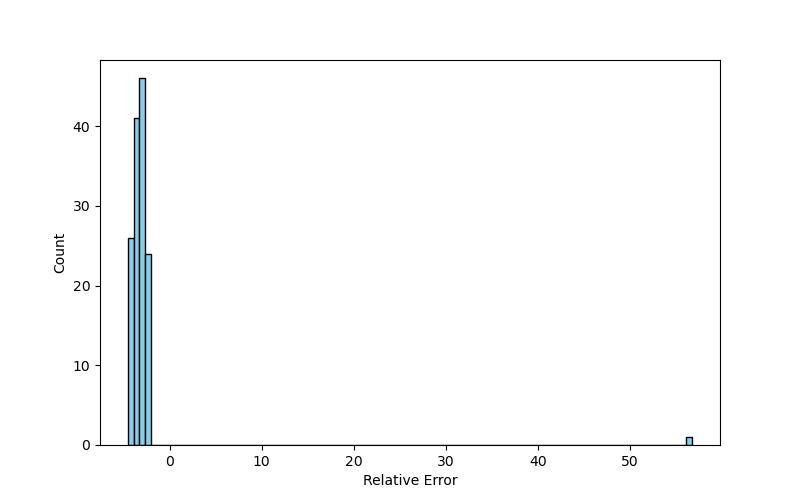

In [22]:
aug_both["Var_TH"] = (1/12)
aug_both["Var_CD_expected"] = (0.314)**2
aug_both["var_r_ed_trace"] = aug_df["var_r_ed_trace"]

# New derived CD variance using ED-anchored DN moments
aug_both["Var_CD_derived"] = (
    aug_both["var_r_dn_trace_edref"] - aug_both["var_r_ed_trace"] - aug_both["Var_TH"]
)

# Relative error
aug_both["Error_rel"] = (
    (aug_both["Var_CD_expected"] - aug_both["Var_CD_derived"]) / aug_both["Var_CD_expected"]
)

plt.figure(figsize=(8,5))

plt.hist(aug_both["Error_rel"], bins=100, color="skyblue", edgecolor="k")
plt.xlabel("Relative Error")
plt.ylabel("Count")
plt.show()

μ = -3.311861, σ = 0.566915, variance = 0.321393


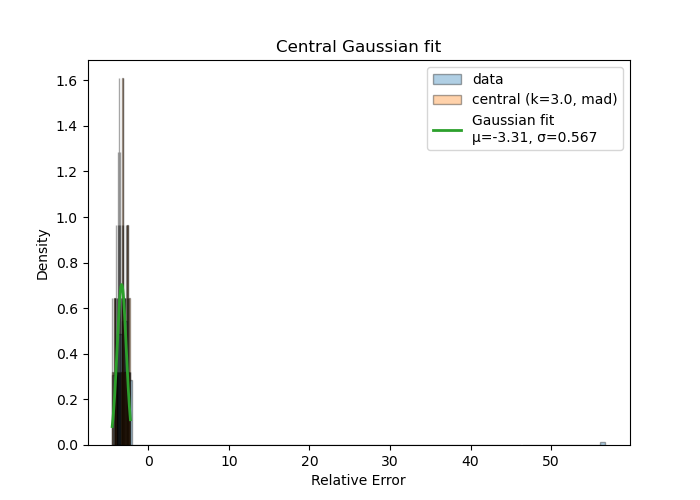

In [23]:
mu, sigma, var, mask = fit_gaussian_central(aug_both["Error_rel"], clip_method="mad", k=3.0, bins=100)
print(f"μ = {mu:.6f}, σ = {sigma:.6f}, variance = {var:.6f}")

In [24]:
aug_both.head(10)

,mean_x_um,mean_y_um,mean_x_px,mean_y_px,std_x_um,std_y_um,std_x_px,std_y_px,sigma_r_ed,count,...,cov_xy_edref,sigma_major_edref,sigma_minor_edref,sigma_r_dn_trace_edref,var_r_dn_trace_edref,Var_TH,Var_CD_expected,var_r_ed_trace,Var_CD_derived,Error_rel
parent_pid,,,,,,,,,,,,,,,,,,,,,
16384,17467.704894,18096.205967,1746.770489,1809.620597,1.318560,2.179724,0.131856,0.217972,0.169532,101,...,0.377204,0.955596,0.395776,0.731370,0.534902,0.083333,0.098596,0.032449,0.419119,-3.250875
33570816,32861.101047,23777.641286,3286.110105,2377.764129,0.700168,2.051489,0.070017,0.205149,0.119849,2750,...,0.264062,0.882556,0.482148,0.711116,0.505686,0.083333,0.098596,0.023494,0.398858,-3.045380
33587200,37302.169744,11187.763549,3730.216974,1118.776355,1.073046,1.322238,0.107305,0.132224,0.119114,2056,...,0.303509,0.910346,0.457599,0.720461,0.519064,0.083333,0.098596,0.014499,0.421232,-3.272300
33603584,11960.786093,7562.050408,1196.078609,756.205041,0.495597,1.185296,0.049560,0.118530,0.076644,392,...,0.208364,0.805131,0.479118,0.662492,0.438895,0.083333,0.098596,0.008253,0.347309,-2.522549
33685504,30868.297725,11496.792536,3086.829773,1149.679254,6.906489,1.950538,0.690649,0.195054,0.367034,944,...,0.083841,0.907597,0.718324,0.818450,0.669861,0.083333,0.098596,0.257521,0.329007,-2.336916
872431616,10631.140506,25131.241868,1063.114051,2513.124187,2.528300,2.006027,0.252830,0.200603,0.225207,118574,...,0.293401,0.926676,0.519355,0.751151,0.564229,0.083333,0.098596,0.052082,0.428813,-3.349193
33619968,27190.173831,14549.065571,2719.017383,1454.906557,0.099385,0.534359,0.009939,0.053436,0.023045,53,...,0.295034,0.923192,0.508705,0.745340,0.555532,0.083333,0.098596,0.001477,0.470722,-3.774251
67174400,21870.185039,31592.034078,2187.018504,3159.203408,0.180113,0.718277,0.018011,0.071828,0.035968,160,...,0.237317,0.848697,0.489630,0.692829,0.480012,0.083333,0.098596,0.002742,0.393937,-2.995464
35209216,29661.744361,18642.482710,2966.174436,1864.248271,0.820613,0.983265,0.082061,0.098327,0.089827,908,...,0.236010,0.849515,0.461017,0.683452,0.467107,0.083333,0.098596,0.008201,0.375572,-2.809203


In [25]:
aug_both["Var_TH"] = 1.0/12.0

microns_per_pixel = 10.0

need = {"std_x_px", "std_y_px"}
have = set(aug_both.columns)
to_add = list(need - have)

if to_add:
    src = stats_df.copy()
    # if stds are in microns, convert once
    if "std_x_px" in to_add and "std_x_px" not in src.columns and "std_x_um" in src.columns:
        src["std_x_px"] = src["std_x_um"] / microns_per_pixel
    if "std_y_px" in to_add and "std_y_px" not in src.columns and "std_y_um" in src.columns:
        src["std_y_px"] = src["std_y_um"] / microns_per_pixel

    # filter to just the columns we still need (and that exist)
    to_add = [c for c in to_add if c in src.columns]
    if to_add:
        aug_both = aug_both.join(src[to_add], how="left")

# 2) Build ED trace variance in px²
aug_both["var_r_ed_trace"] = 0.5*(aug_both["std_x_px"]**2 + aug_both["std_y_px"]**2)

# 3) Sanity checks (catch unit/alignment problems early)
def _check(name, s):
    arr = s.to_numpy(dtype=float)
    ok = np.isfinite(arr)
    print(f"{name}: n={ok.sum()} finite, min={np.nanmin(arr):.4g}, "
          f"median={np.nanmedian(arr):.4g}, max={np.nanmax(arr):.4g}")

_check("var_r_dn_trace_edref", aug_both["var_r_dn_trace_edref"])
_check("var_r_ed_trace     ", aug_both["var_r_ed_trace"])
_check("Var_TH             ", aug_both["Var_TH"])

# 4) Derived CD variance (ED-anchored DN moments) and error
aug_both["Var_CD_derived"]  = aug_both["var_r_dn_trace_edref"] - aug_both["var_r_ed_trace"] - aug_both["Var_TH"]
aug_both["Var_CD_expected"] = (0.314)**2
aug_both["Error_rel"]       = (aug_both["Var_CD_expected"] - aug_both["Var_CD_derived"]) / aug_both["Var_CD_expected"]


var_r_dn_trace_edref: n=138 finite, min=0.426, median=0.5324, max=7.722
var_r_ed_trace     : n=138 finite, min=7.705e-05, median=0.009016, max=13.13
Var_TH             : n=138 finite, min=0.08333, median=0.08333, max=0.08333


       Var_CD_derived  Var_CD_expected   Error_rel
count      138.000000     1.380000e+02  138.000000
mean         0.382234     9.859600e-02   -2.876768
std          0.507032     1.392834e-16    5.142526
min         -5.494847     9.859600e-02   -4.490957
25%          0.379123     9.859600e-02   -3.741363
50%          0.419094     9.859600e-02   -3.250618
75%          0.467479     9.859600e-02   -2.845217
max          0.541386     9.859600e-02   56.730931


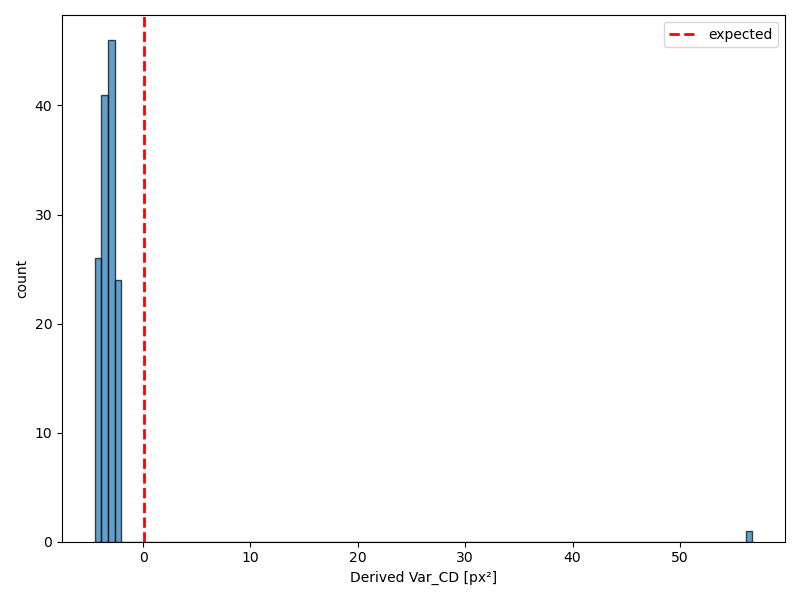

In [27]:
plt.close("all")

# derived CD variance + errors (ED-anchored DN)
aug_both["Var_CD_derived"]  = aug_both["var_r_dn_trace_edref"] - aug_both["var_r_ed_trace"] - aug_both["Var_TH"]
aug_both["Error_rel"]       = (aug_both["Var_CD_expected"] - aug_both["Var_CD_derived"]) / aug_both["Var_CD_expected"]

# Quick stats
summary = aug_both[["Var_CD_derived","Var_CD_expected","Error_rel"]].describe()
print(summary)

# Histogram of derived variance vs expected
plt.figure(figsize=(8,6))
plt.hist(aug_both["Error_rel"], bins=100, edgecolor="k", alpha=0.7)
plt.axvline(aug_both["Var_CD_expected"].iloc[0], color="red", ls="--", lw=2, label="expected")
plt.xlabel("Derived Var_CD [px²]"); plt.ylabel("count"); plt.legend(); plt.tight_layout(); plt.show()

# Save a slim results table
keep = ["pid_label","var_r_dn_trace_edref","var_r_ed_trace","Var_TH","Var_CD_derived","Error_rel"]
(aug_both[keep] if "pid_label" in aug_both.columns else aug_both[keep[1:]]).to_csv("cd_variance_results.csv", index=True)
